In [1]:
# run only if CUTEST is not properly installed (try without running first and see if you get an error)
import os
os.environ["MASTSIF"] = "/home/karima04/cutest/mastsif/"

In [2]:
import k_fail_GPS
import k_fail_MBTR
import k_fail_GPS_MBTR_hybrid
import BB_wrapper
import k_fail_prediction

import torch

/home/karima04/k-sPSS/.venv/lib/python3.12/site-packages/pycutest/__init__.py:26: RuntimeWarning: the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.
  warnings.warn("the PYCUTEST_CACHE environment variable is not set; current folder will be used for caching.", RuntimeWarning)


# cleanup

In [67]:
import os
from collections import Counter

abnormalities_path = "alg_logs/abnormalities.txt"  # adjust if needed

counts = Counter()

with open(abnormalities_path) as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split(" AT ")
        if len(parts) < 2:
            continue
        p_name = parts[0].strip()
        counts[p_name] += 1

print(f"{'problem':>16} | abnormal evaluations")
print("-" * 40)
for p_name in sorted(counts):
    print(f"{p_name:>16} | {counts[p_name]}")

print(f"\n{len(counts)} distinct problems with abnormalities, {sum(counts.values())} total lines.")

         problem | abnormal evaluations
----------------------------------------
=== END OF HYBRID 2 NON ORTH ===DENSCHNC | 1
         BA-L1LS | 836
      BENNETT5LS | 37
          BIGGS6 | 3
        BOXBODLS | 385
      CERI651ALS | 1990
      CERI651BLS | 1609
      CERI651CLS | 1302
      CERI651DLS | 712
      CERI651ELS | 707
           CLIFF | 93
      DANIWOODLS | 1
       DANWOODLS | 11790
        DENSCHNC | 2
        DENSCHNE | 6
         DEVGLA1 | 1993
         DEVGLA2 | 31263
      DIAMON3DLS | 1
          EXPFIT | 27
        GAUSS1LS | 2067
        GAUSS2LS | 1849
        GAUSS3LS | 1911
        GROWTHLS | 31
            GULF | 1
         HATFLDD | 2
         HATFLDE | 1
        HIMMELBB | 5
        HIMMELBG | 5
        HIMMELBH | 113
          JENSMP | 40
      LANCZOS1LS | 12
      LANCZOS2LS | 145
      LANCZOS3LS | 12
      LUKSAN15LS | 205
      LUKSAN16LS | 222
        MGH10SLS | 78
         MGH17LS | 46688
        MGH17SLS | 1319
       MISRA1ALS | 531
       MISRA1C

In [ ]:
file_path = "alg_logs_data_run/cutest_problem_selection_hyperparam_tuning.txt"  # adjust

exclude = [
    "SISSER",
    "CHWIRUT2LS", # abnormal
    "DENSCHNB",
    "GBRAINLS",
    "MGH10LS", # abnormal
    "QING",
    "BOX3", # abnormal
    "DENSCHNC",
    "LANCZOS3LS", # abnormal - even with good params
    "GAUSS1LS", # abnormal - even with good params
    "MGH09LS",
    "LANCZOS1LS", # abnormal - even with good params
    "BA-L1LS", # abnormal - even with good params
    "GAUSS3LS", # abnormal - even with good params
    "DENSCHNA",
    "NELSONLS", # abnormal - even with good params
    "LUKSAN21LS",
    "VANDANMSLS",
    "SENSORS",
    "DENSCHND", # abnormal
    "DANWOODLS", # abnormal - even with good params
    "CUBE",
    "MUONSINELS",
    "DENSCHNE", # abnormal
    "DMN15333LS",
    "DIAMON3DLS", # abnormal during data run
    "EXPFIT", # abnormal - during data run too
    "HELIX",
    "LSC2LS",
    "KOWOSB",
    "S308",
    "DANIWOODLS",
    "DENSCHNF",
    "LRIJCNN1",
    "YFITU",
    "GAUSS2LS", # abnormal - even with good params
    "CHWIRUT1LS", # abnormal
    "COOLHANSLS",
    "HAHN1LS",
    "HIMMELBB", # abnormal - during data run too
    ]

names = []
with open(file_path) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("id"):   # skip header / blanks
            continue
        parts = line.split("|")
        if len(parts) < 2:
            continue
        name = parts[1].strip()
        if name and name not in exclude:
            names.append(name)

print(f"{len(names)} names kept (excluded {len(exclude)}):\n")
# print as a paste-ready Python list
for name in names:
    print(f'    "{name}",')

In [2]:
import re
import os

dirs = [
    "alg_logs_data_run/GPS/timeout_list.txt",
    "alg_logs_data_run/MBTR/timeout_list.txt",
    "alg_logs_data_run/MBTR_GPS_hybrid/timeout_list.txt",
]

timeouts = {}  # problem_name -> count

for path in dirs:
    if not os.path.exists(path):
        continue
    with open(path) as f:
        for line in f:
            m = re.match(r"TIME LIMIT REACHED ON: (\S+)", line)
            if m:
                name = m.group(1)
                timeouts[name] = timeouts.get(name, 0) + 1

print(f"{'problem':>20} | count")
print("-" * 35)
for name, count in sorted(timeouts.items(), key=lambda x: -x[1]):
    print(f"{name:>20} | {count}")

             problem | count
-----------------------------------


In [3]:
import os
import re
import ast

PROBLEM_NAME = "QING"  # change this

dirs = {
    "MBTR": "alg_logs_data_run/MBTR",
    "Hybrid": "alg_logs_data_run/MBTR_GPS_hybrid",
}

# parse n_batch_calls from last line of log file
def read_last_n_batch_calls(filepath):
    last_line = None
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("k"):
                last_line = line
    if last_line is None:
        return None
    parts = [p.strip() for p in last_line.split("|")]
    if len(parts) < 5:
        return None
    try:
        counters = ast.literal_eval(parts[4].strip())
        return counters[3]  # n_batch_calls
    except Exception:
        return None

pattern = re.compile(r'_batchlim(\d+)_')

best_ratio = float('inf')
best_file = None
best_info = None

for alg, d in dirs.items():
    if not os.path.exists(d):
        continue
    for fname in os.listdir(d):
        if not fname.startswith(f"data_generation_{PROBLEM_NAME}_"):
            continue

        m = pattern.search(fname)
        if not m:
            continue
        budget = int(m.group(1))

        filepath = os.path.join(d, fname)
        n_batch_calls = read_last_n_batch_calls(filepath)
        if n_batch_calls is None:
            continue

        ratio = n_batch_calls / budget
        if ratio < best_ratio:
            best_ratio = ratio
            best_file = fname
            best_info = (alg, n_batch_calls, budget)

if best_file:
    alg, n_batch_calls, budget = best_info
    print(f"Best ratio: {best_ratio:.4f} ({n_batch_calls} / {budget})")
    print(f"Algorithm: {alg}")
    print(f"File: {best_file}")
else:
    print(f"No files found for problem: {PROBLEM_NAME}")

Best ratio: 1.0000 (1000 / 1000)
Algorithm: MBTR
File: data_generation_QING_cluster64_k4_kassumed0_delta1.00_mu2.00_eta0.10_gamma0.50_epsstop0.00_preford1_batchlim1000_oppcpulim600_opp_orth_smallhat_mbtr.txt


# Defining the set

In [3]:
alg_names = [
    "GPS-opp-optimistic",
    "GPS-comp-optimistic",
    "GPS-opp-realistic",
    "GPS-comp-realistic",
    "GPS-opp-pessimistic",
    "GPS-comp-pessimistic",

    "MBTR-1-comp-purerand-optimistic",
    "MBTR-1-comp-orth-optimistic",
    "MBTR-1-opp-purerand-optimistic",
    "MBTR-1-opp-orth-optimistic",
    "MBTR-1-comp-purerand-realistic",
    "MBTR-1-comp-orth-realistic",
    "MBTR-1-opp-purerand-realistic",
    "MBTR-1-opp-orth-realistic",
    "MBTR-1-comp-purerand-pessimistic",
    "MBTR-1-comp-orth-pessimistic",
    "MBTR-1-opp-purerand-pessimistic",
    "MBTR-1-opp-orth-pessimistic",
    
    "Hybrid-1-comp-purerand-optimistic",
    "Hybrid-1-comp-orth-optimistic",
    "Hybrid-1-comp-gps-optimistic",
    "Hybrid-1-opp-purerand-optimistic",
    "Hybrid-1-opp-orth-optimistic",
    "Hybrid-1-opp-gps-optimistic",
    "Hybrid-1-comp-purerand-realistic",
    "Hybrid-1-comp-orth-realistic",
    "Hybrid-1-comp-gps-realistic",
    "Hybrid-1-opp-purerand-realistic",
    "Hybrid-1-opp-orth-realistic",
    "Hybrid-1-opp-gps-realistic",
    "Hybrid-1-comp-purerand-pessimistic",
    "Hybrid-1-comp-orth-pessimistic",
    "Hybrid-1-comp-gps-pessimistic",
    "Hybrid-1-opp-purerand-pessimistic",
    "Hybrid-1-opp-orth-pessimistic",
    "Hybrid-1-opp-gps-pessimistic",
]

NUM_ALGS = len(alg_names)

NUM_PROBLEMS = 161 - 11 - 25 # 11 total from 40-subset (3 more problems were dropped), 25 from rest

# Test Set

In [4]:
cutest_wrapper = BB_wrapper.BB_cutest_collection(write_to_file="alg_logs_data_run/cutest_problem_selection_hyperparam_tuning.txt", max_dim=100, cap_n_problems=NUM_PROBLEMS,
                problem_names=[
    "SISSER",
    "CHWIRUT2LS", # abnormal
    "DENSCHNB",
    "GBRAINLS",
    "MGH10LS", # abnormal
    "QING",
    "BOX3", # abnormal
    "DENSCHNC",
    # "LANCZOS3LS", # abnormal - even with good params
    # "GAUSS1LS", # abnormal - even with good params
    "MGH09LS",
    # "LANCZOS1LS", # abnormal - even with good params
    # "BA-L1LS", # abnormal - even with good params
    # "GAUSS3LS", # abnormal - even with good params
    "DENSCHNA",
    # "NELSONLS", # abnormal - even with good params
    "LUKSAN21LS",
    "VANDANMSLS",
    "SENSORS",
    "DENSCHND", # abnormal
    # "DANWOODLS", # abnormal - even with good params
    "CUBE",
    "MUONSINELS",
    "DENSCHNE", # abnormal
    "DMN15333LS",
    # "DIAMON3DLS", # abnormal during data run
    # "EXPFIT", # abnormal - during data run too
    "HELIX",
    "LSC2LS",
    "KOWOSB",
    "S308",
    "DANIWOODLS",
    "DENSCHNF",
    "LRIJCNN1",
    "YFITU",
    # "GAUSS2LS", # abnormal - even with good params
    "CHWIRUT1LS", # abnormal
    "COOLHANSLS",
    "HAHN1LS",
    # "HIMMELBB", # abnormal - during data run too

    # rest of set
    "JUDGE",
    "HYDCAR6LS",
    # "MGH10SLS", # abnormal on data_run
    "BARD",
    "POWELLBSLS",
    # "RAT43LS", # abnormal on data_run
    "HUMPS",
    "ROSENBR",
    # "MISRA1ALS", # abnormal on data_run
    # "BOXBODLS", # abnormal on data_run
    "METHANB8LS",
    # "STREG", # abnormal on data_run
    # "DEVGLA1", # abnormal on data_run
    # "MGH17SLS", # abnormal on data_run
    "EGGCRATE",
    "HAIRY",
    "DJTL",
    "HATFLDFL",
    "HIMMELBF",
    "LRCOVTYPE",
    "LUKSAN17LS",
    # "CERI651BLS", # abnormal on data_run
    "BEALE",
    "HEART8LS",
    "CHNROSNB",
    "STRTCHDV",
    "WATSON",
    # "LUKSAN16LS", # abnormal on data_run
    "SINEVAL",
    "TRIGON2",
    "CHNRSNBM",
    "DMN37143LS",
    # "LUKSAN15LS", # abnormal on data_run
    "LOGHAIRY",
    "ERRINROS",
    "BA-L1SPLS",
    "VESUVIOLS",
    "PARKCH",
    "HIELOW",
    "BRKMCC",
    "MISRA1BLS",
    "BROWNBS",
    # "HIMMELBH", # abnormal on data_run
    "HIMMELBCLS",
    "WAYSEA1",
    "HIMMELBG",
    "POWELLSQLS",
    # "MGH17LS", # abnormal on data_run
    "MARATOSB",
    "EXP2",
    "RECIPELS",
    "FBRAIN3LS",
    "MISRA1DLS",
    "VIBRBEAM",
    "ECKERLE4LS",
    "MANCINO",
    "SNAIL",
    # "OSBORNEA", # abnormal on data_run
    # "GROWTHLS", # abnormal on data_run
    "THURBERLS",
    "POWERSUM",
    "DIXMAANA1",
    "LUKSAN11LS",
    "GAUSSIAN",
    "LUKSAN14LS",
    "SISSER2",
    "PALMER6C",
    # "BENNETT5LS", # abnormal on data_run
    # "DEVGLA2", # abnormal on data_run
    "ENSOLS",
    "VESUVIOULS",
    "HATFLDE",
    "HYDC20LS",
    # "CERI651ALS", # abnormal on data_run
    "STRATEC",
    "DMN15332LS",
    # "CLIFF", # abnormal on data_run
    "CLUSTERLS",
    "ENGVAL2",
    "METHANL8LS",
    "ROSENBRTU",
    "KIRBY2LS",
    "PRICE3",
    "TOINTGOR",
    # "JENSMP", # abnormal on data_run
    "PRICE4",
    # "CERI651ELS", # abnormal on data_run
    "WAYSEA2",
    "DIAMON2DLS",
    "HEART6LS",
    "ALLINITU",
    "RAT42LS",
    "YATP2LS",
    "LUKSAN13LS",
    # "CERI651CLS", # abnormal on data_run
    "ROSZMAN1LS",
    "MEXHAT",
    "HATFLDD",
    "SSI",
    "HATFLDFLS",
    "TOINTPSP",
    "VESUVIALS",
    # "MISRA1CLS", # abnormal on data_run
    # "OSBORNEB", # abnormal on data_run
    # "LANCZOS2LS", # abnormal on data_run
    "MEYER3",
    "DMN37142LS",
    "GULF",
    "LSC1LS",
    # "CERI651DLS", # abnormal on data_run
    "LUKSAN22LS",
    "TRIGON1",
    "AKIVA",
    "ERRINRSM",
    "DMN15102LS",
    "HATFLDGLS",
    "BIGGS6",
    "ELATVIDU",
    "LUKSAN12LS",
    "DMN15103LS",
    "BROWNDEN",
    ]
)

# 8 problems that break even with good params
# problem |         max norm |                 f(x) | point
# ----------------------------------------------------------------------------------------------------
#          BA-L1LS |         990.5243 |         9.219979e+21 | [-0.7446797668400358, -0.5794640963847512, -3.500486499158188, -1.323064012068379, -0.8821493419036788, -1.153266032451207, -1.037392399990249, -1.7370471505998548, -0.17264920003296513, -0.4199224842103658, 0.554345516022883, 400.32507031390696, 0.5155897025421708, 0.3353901881454257, -1.0909267718088276, 0.6574185667019381, 0.004708728385872163, 1.559525356418754, -0.25605862627329956, 0.6835794392982492, 403.2747372135689, -1.2256417192317774, 1.3594889258775074, -1.5979727812800866, -1.0860927258990598, 1.5105830155390567, -0.29574298935971965, 0.18619405401275946, -1.5642689391963902, 402.0687289118412, -0.2616010582518473, 0.06891134488748785, -0.9446102477864426, -1.0731416075359488, -1.3379491284948843, -0.99565881271732, -1.1728883749045516, 0.5812987787646552, 408.29874934964937, -0.11559198901642201, 0.13525565863270428, -1.3489024022805156, -2.3137113543778423, 0.49262514747475517, -0.785366139956941, -0.506207567601328, -1.9268780779095296, 406.02145117197347, -0.5096040443748667, -0.6721877138836985, 0.47587316574278804, -0.17102787064680636, -1.8429799248670111, 0.07077613383914438, 0.8619971105045817, 1.6253086384384314, 406.155553922073]
#        DANWOODLS |           9.3062 |                  nan | [-2.834344446659088, 8.864126235246658]
#         GAUSS1LS |         247.8049 |         2.742551e+56 | [97.36571794748306, -0.23966244196891784, 100.08577281236649, 66.2136663198471, 19.28817927837372, 69.28813630342484, 179.0735146999359, 16.897746235132217]
#         GAUSS2LS |         245.4660 |         2.686505e+56 | [96.36571794748306, -0.23966244196891784, 103.08577281236649, 107.2136663198471, 17.28817927837372, 71.28813630342484, 152.0735146999359, 18.397746235132217]
#         GAUSS3LS |         237.7268 |        2.236339e+114 | [95.27756401300431, -0.5074717435836792, 90.63045934438705, 113.69683742523193, 20.402080088853836, 74.77810739278793, 140.9900802373886, 20.220720440149307]
#       LANCZOS1LS |          67.8451 |         1.918248e+31 | [19.08627117872238, -28.728440307825803, 33.668587347865106, 33.67619502544403, 19.488707780838013, 27.674590772390367]
#       LANCZOS3LS |          67.8451 |         1.918248e+31 | [19.08627117872238, -28.728440307825803, 33.668587347865106, 33.67619502544403, 19.488707780838013, 27.674590772390367]
#         NELSONLS |           6.3727 |        2.832579e+284 | [4.01845096051693, 4.806541366672516, -1.1663485860824585]

loading problems...
0/125
20/125
40/125
60/125
80/125
100/125
120/125
loaded 125 problems


In [5]:
# evaluating n problem functions
for i in range(NUM_PROBLEMS):
    p = cutest_wrapper.problems[i]
    f = cutest_wrapper.problem_functions[i]
    print(f"idx: {i} | {p.name} | n: {p.n}: {f(torch.from_numpy(p.x0))}")

idx: 0 | SISSER | n: 2: 3.02030030003
idx: 1 | CHWIRUT2LS | n: 3: 14794.790154797307
idx: 2 | DENSCHNB | n: 2: 6.0
idx: 3 | GBRAINLS | n: 2: 41.0311021275977
idx: 4 | MGH10LS | n: 3: 4515242701191391.0
idx: 5 | QING | n: 100: 328350.0
idx: 6 | BOX3 | n: 3: 1.8845685008804969
idx: 7 | DENSCHNC | n: 2: 889.3031475218829
idx: 8 | MGH09LS | n: 4: 897.5453780404946
idx: 9 | DENSCHNA | n: 2: 7.952492442012559
idx: 10 | LUKSAN21LS | n: 100: 99.98750720029557
idx: 11 | VANDANMSLS | n: 22: 15.000017496625823
idx: 12 | SENSORS | n: 100: -56.48140005456502
idx: 13 | DENSCHND | n: 3: 83210000.0
idx: 14 | CUBE | n: 2: 749.0383999999999
idx: 15 | MUONSINELS | n: 1: 61302.97680759
idx: 16 | DENSCHNE | n: 3: 148.99932918727936
idx: 17 | DMN15333LS | n: 99: 484133.4482526387
idx: 18 | HELIX | n: 3: 2499.999798289702
idx: 19 | LSC2LS | n: 3: 235144.35341171772
idx: 20 | KOWOSB | n: 4: 0.005313615358191823
idx: 21 | S308 | n: 2: 87.68604814559544
idx: 22 | DANIWOODLS | n: 2: 149.71921907712198
idx: 23 | 

     n num_problems
--------------------
     1            1
     2           39
     3           25
     4            7
     5            1
     6            3
     7            2
     8            7
     9            2
    10            4
    12            1
    15            1
    22            2
    25            1
    29            1
    31            2
    50            6
    54            1
    57            1
    66            4
    98            3
    99            4
   100            7


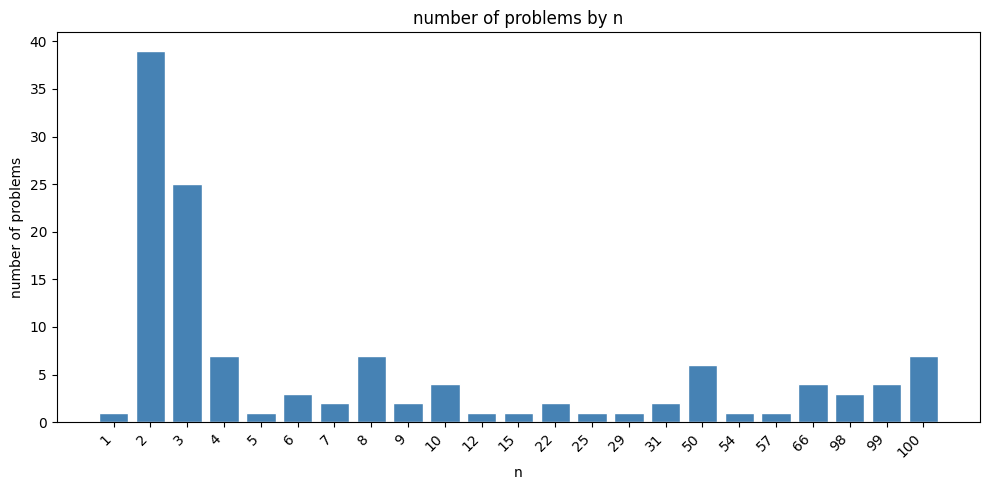

In [6]:
from collections import Counter 
import matplotlib.pyplot as plt

def count_problems_by_n(filepath: str) -> None:
    counter = Counter()
 
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('|')
            if len(parts) < 4:
                continue
            try:
                n = int(parts[3].strip())
                counter[n] += 1
            except ValueError:
                continue  # skip header or malformed lines
 
    print(f"{'n':>6} {'num_problems':>12}")
    print("-" * 20)
    for n in sorted(counter):
        print(f"{n:>6} {counter[n]:>12}")
 
    ns = sorted(counter)
    counts = [counter[n] for n in ns]
 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar([str(n) for n in ns], counts, color="steelblue", edgecolor="white")
    ax.set_xlabel("n")
    ax.set_ylabel("number of problems")
    ax.set_title("number of problems by n")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

count_problems_by_n("alg_logs_data_run/cutest_problem_selection_hyperparam_tuning.txt")

# Algorithm Wrappers

In [7]:
import time
import os

TIME_LIMIT_S = 3600.0

def read_last_fx(filename):
    last_fx = None
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            # Skip header and empty lines
            if not line or line.startswith("k"):
                continue
            parts = [p.strip() for p in line.split("|")]
            if len(parts) >= 3:
                try:
                    last_fx = float(parts[2])
                except ValueError:
                    pass
    return last_fx

In [8]:
def gps_path_batch_constrained(problem_idx, cluster_size, k, k_assumed, delta, tao, n_batch_calls_limit, opportunistic=True):
    log_file_path = f"alg_logs_data_run/GPS/data_generation_{cutest_wrapper.problems[problem_idx].name}_cluster{cluster_size}_k{k}_kassumed{k_assumed}_delta{delta:.2f}_tao{tao:.2f}_batchlim{n_batch_calls_limit}_{'opp' if opportunistic else 'com'}_gps.txt"
    if os.path.exists(log_file_path):
        return log_file_path
    
    GPS_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((4096, 2), dtype=torch.int16), cluster_size)
    alg = k_fail_GPS.GPS_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), GPS_expl_k_fail_wrapper, delta, tao, prediction_software=k_fail_prediction.constant_prediction_software(k_assumed), log_file_path=log_file_path, use_opportunistic_cpu_exploitation=opportunistic) # are true by default

    alg.log_current(message=f"k={k}")
    
    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs_data_run/GPS/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {cutest_wrapper.problems[problem_idx].name} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default(random_rotate=True)
    
    return log_file_path

In [9]:
def mbtr_path_batch_constrained(problem_idx, cluster_size, k, k_assumed, delta, mu, eta, gamma, eps_stop, preferred_model_order, n_batch_calls_limit, opportunistic_cpu_exploitation_manual_point_limit, opportunistic=True, orthogonal=True, use_reasoned_k_hat=True):
    log_file_path = f"alg_logs_data_run/MBTR/data_generation_{cutest_wrapper.problems[problem_idx].name}_cluster{cluster_size}_k{k}_kassumed{k_assumed}_delta{delta:.2f}_mu{mu:.2f}_eta{eta:.2f}_gamma{gamma:.2f}_epsstop{eps_stop:.2f}_preford{preferred_model_order}_batchlim{n_batch_calls_limit}_oppcpulim{opportunistic_cpu_exploitation_manual_point_limit}_{'opp' if opportunistic else 'com'}_{"orth" if orthogonal else "purerand"}_{'smallhat' if use_reasoned_k_hat else 'safehat'}_mbtr.txt"
    if os.path.exists(log_file_path):
        return log_file_path

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), cluster_size)

    alg = k_fail_MBTR.MBTR_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k_assumed), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order,
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit,
                                  use_opportunistic_cpu_exploitation=opportunistic,
                                  use_orthogonal=orthogonal,
                                  use_reasoned_k_hat=use_reasoned_k_hat)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs_data_run/MBTR/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {cutest_wrapper.problems[problem_idx].name} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    return log_file_path

In [10]:
def mbtr_gps_hybrid_path_batch_constrained(problem_idx, cluster_size, k, k_assumed, delta, mu, eta, gamma, eps_stop, preferred_model_order, n_batch_calls_limit, opportunistic_cpu_exploitation_manual_point_limit, opportunistic=True, set_type="purerand", use_reasoned_k_hat=True):
    log_file_path = f"alg_logs_data_run/MBTR_GPS_hybrid/data_generation_{cutest_wrapper.problems[problem_idx].name}_cluster{cluster_size}_k{k}_kassumed{k_assumed}_delta{delta:.2f}_mu{mu:.2f}_eta{eta:.2f}_gamma{gamma:.2f}_epsstop{eps_stop:.2f}_preford{preferred_model_order}_batchlim{n_batch_calls_limit}_oppcpulim{opportunistic_cpu_exploitation_manual_point_limit}_{'opp' if opportunistic else 'com'}_{set_type}_{'smallhat' if use_reasoned_k_hat else 'safehat'}_hybrid.txt"
    if os.path.exists(log_file_path):
        return log_file_path

    MBTR_expl_k_fail_wrapper = BB_wrapper.BB_k_fail_wrapper(cutest_wrapper.problem_functions[problem_idx], k*torch.ones((1024, 2), dtype=torch.int16), cluster_size)

    alg = k_fail_GPS_MBTR_hybrid.MBTR_GPS_hybrid_k_fail(torch.from_numpy(cutest_wrapper.problems[problem_idx].x0), MBTR_expl_k_fail_wrapper, delta, mu, eta, gamma, eps_stop, prediction_software=k_fail_prediction.constant_prediction_software(k_assumed), log_file_path=log_file_path,
                                  preferred_model_order=preferred_model_order,
                                  opportunistic_cpu_exploitation_manual_point_limit=opportunistic_cpu_exploitation_manual_point_limit,
                                  use_opportunistic_cpu_exploitation=opportunistic,
                                  set_type=set_type,
                                  use_reasoned_k_hat=use_reasoned_k_hat)
    
    alg.log_current()

    start_time = time.time()

    while alg.n_batch_calls < n_batch_calls_limit:
        if time.time() - start_time >= TIME_LIMIT_S:
            with open("alg_logs_data_run/MBTR_GPS_hybrid/timeout_list.txt", "a") as f:
                f.write(f"TIME LIMIT REACHED ON: {cutest_wrapper.problems[problem_idx].name} | {cutest_wrapper.problems[problem_idx]} | x_k = {alg.x} | f(x) = {alg.cur_f_val}\n")
            break
        alg.step_default()
    
    return log_file_path

# GPS and MBTR hyperparameters and cluster settings

In [11]:
dim_to_cluster_sizes = { # upper inclusive : [possible ranges]
    4: [4],
    16: [4, 16],
    100: [16, 64]
}

cluster_size_to_k_vals = { # cluster size: possible k values
    4: [0, 1],
    16: [0, 1, 2, 4],
    64: [0, 4, 8, 16]
}

k_assumed_functions = {
    "optimistic": lambda _cluster_size, _k_actual: 0,
    "realistic": lambda _cluster_size, _k_actual: _k_actual,
    "pessimistic": lambda _cluster_size, _k_actual: cluster_size_to_k_vals[_cluster_size][-1],
}


# GPS
gps_delta = 1.0
gps_tau = 0.3

# MBTR ORDER 1
mbtr_1_delta = 1.0
mbtr_1_mu = 2.0
mbtr_1_eta = 0.1
mbtr_1_gamma = 0.5
mbtr_1_eps_stop = 0.0

# MBTR ORDER 2
mbtr_2_delta = 1.0
mbtr_2_mu = 2.0
mbtr_2_eta = 0.1
mbtr_2_gamma = 0.5
mbtr_2_eps_stop = 0.0

# batch limit depended on dim
batch_limit_func = lambda n: 10 * n
# MBTR function limit
mbtr_model_function_lim = lambda n: 6*n

# Run the algorithms

In [12]:
def get_cluster_sizes(n):
    for k, v in dim_to_cluster_sizes.items():
        if n <= k:
            return v
    
    raise Exception("did not find cluster size range for supplied dim")

In [13]:
from IPython.display import clear_output
from tqdm.notebook import tqdm
import math

log_paths = [[] for _ in range(NUM_ALGS)]

In [14]:
current_path_idx = 0

GPS

In [15]:
gps_combination_count = 0 
for problem_idx in range(NUM_PROBLEMS):
    problem_n = cutest_wrapper.problems[problem_idx].n
    cluster_sizes = get_cluster_sizes(problem_n)
    for cluster_size in cluster_sizes:
        ks = cluster_size_to_k_vals[cluster_size]
        for k in ks:
            gps_combination_count += 1

def gps_all_combinations(path_idx, k_assumed_f, opportunistic):
    pbar = tqdm(total=gps_combination_count)
    
    for problem_idx in range(NUM_PROBLEMS):
        problem_n = cutest_wrapper.problems[problem_idx].n

        cluster_sizes = get_cluster_sizes(problem_n)
        
        for cluster_size in cluster_sizes:
            ks = cluster_size_to_k_vals[cluster_size]

            for k in ks:
                log_paths[path_idx].append(gps_path_batch_constrained(problem_idx, cluster_size, k, k_assumed_f(cluster_size, k), gps_delta, gps_tau, batch_limit_func(problem_n), opportunistic))

                clear_output(wait=True)
                pbar.update(1)

    pbar.close()

In [16]:
for k_assumed_f in k_assumed_functions.values():
    # GPS - opportunistic
    gps_all_combinations(current_path_idx, k_assumed_f, True)
    # GPS - complete
    gps_all_combinations(current_path_idx+1, k_assumed_f, False)

    current_path_idx += 2

  0%|          | 0/526 [00:00<?, ?it/s]

MBTR

In [17]:
mbtr_combination_count = 0
for problem_idx in range(NUM_PROBLEMS):
    problem_n = cutest_wrapper.problems[problem_idx].n
    cluster_sizes = get_cluster_sizes(problem_n)
    for cluster_size in cluster_sizes:
        ks = cluster_size_to_k_vals[cluster_size]
        for k in ks:
            mbtr_combination_count += 1

def mbtr_all_combinations(path_idx, k_assumed_f, order, opportunistic, orthogonal, use_reasoned_k_hat):
    pbar = tqdm(total=mbtr_combination_count)
    pbar.set_description(f"order{order}_{"opp" if opportunistic else "comp"}_{"orth" if orthogonal else "purerand"}_{"smallhat" if use_reasoned_k_hat else "bighat"}")

    for problem_idx in range(NUM_PROBLEMS):
        problem_n = cutest_wrapper.problems[problem_idx].n

        cluster_sizes = get_cluster_sizes(problem_n)
        
        for cluster_size in cluster_sizes:
            ks = cluster_size_to_k_vals[cluster_size]

            for k in ks:
                if order == 1:
                    log_paths[path_idx].append(mbtr_path_batch_constrained(problem_idx, cluster_size, k, k_assumed_f(cluster_size, k), mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, 1, batch_limit_func(problem_n), mbtr_model_function_lim(problem_n), opportunistic, orthogonal, use_reasoned_k_hat))
                else:
                    log_paths[path_idx].append(mbtr_path_batch_constrained(problem_idx, cluster_size, k, k_assumed_f(cluster_size, k), mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, 2, batch_limit_func(problem_n), mbtr_model_function_lim(problem_n), opportunistic, orthogonal, use_reasoned_k_hat))
                
                clear_output(wait=True)
                pbar.update(1)

    pbar.close()

In [18]:
for k_assumed_f in k_assumed_functions.values():
    # all use small hat
    mbtr_all_combinations(current_path_idx, k_assumed_f, 1, False, False, use_reasoned_k_hat=True)
    mbtr_all_combinations(current_path_idx+1, k_assumed_f, 1, False, True, use_reasoned_k_hat=True)
    mbtr_all_combinations(current_path_idx+2, k_assumed_f, 1, True, False, use_reasoned_k_hat=True)
    mbtr_all_combinations(current_path_idx+3, k_assumed_f, 1, True, True, use_reasoned_k_hat=True)

    current_path_idx += 4

  0%|          | 0/526 [00:00<?, ?it/s]

Hybrid

In [19]:
hybrid_combination_count = 0
for problem_idx in range(NUM_PROBLEMS):
    problem_n = cutest_wrapper.problems[problem_idx].n
    cluster_sizes = get_cluster_sizes(problem_n)
    for cluster_size in cluster_sizes:
        ks = cluster_size_to_k_vals[cluster_size]
        for k in ks:
            hybrid_combination_count += 1

def hybrid_all_combinations(path_idx, k_assumed_f, order, opportunistic, set_type, use_reasoned_k_hat):
    pbar = tqdm(total=hybrid_combination_count)
    pbar.set_description(f"order{order}_{"opp" if opportunistic else "comp"}_{set_type}_{"smallhat" if use_reasoned_k_hat else "bighat"}")

    for problem_idx in range(NUM_PROBLEMS):
        problem_n = cutest_wrapper.problems[problem_idx].n

        cluster_sizes = get_cluster_sizes(problem_n)
        
        for cluster_size in cluster_sizes:
            ks = cluster_size_to_k_vals[cluster_size]

            for k in ks:
                if order == 1:
                    log_paths[path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, cluster_size, k, k_assumed_f(cluster_size, k), mbtr_1_delta, mbtr_1_mu, mbtr_1_eta, mbtr_1_gamma, mbtr_1_eps_stop, 1, batch_limit_func(problem_n), mbtr_model_function_lim(problem_n), opportunistic, set_type, use_reasoned_k_hat))
                else:
                    log_paths[path_idx].append(mbtr_gps_hybrid_path_batch_constrained(problem_idx, cluster_size, k, k_assumed_f(cluster_size, k), mbtr_2_delta, mbtr_2_mu, mbtr_2_eta, mbtr_2_gamma, mbtr_2_eps_stop, 2, batch_limit_func(problem_n), mbtr_model_function_lim(problem_n), opportunistic, set_type, use_reasoned_k_hat))

                clear_output(wait=True)
                pbar.update(1)

    pbar.close()

In [20]:
for k_assumed_f in k_assumed_functions.values():
    # all use small hat
    hybrid_all_combinations(current_path_idx, k_assumed_f, 1, False, "purerand", use_reasoned_k_hat=True)
    hybrid_all_combinations(current_path_idx+1, k_assumed_f, 1, False, "orth", use_reasoned_k_hat=True)
    hybrid_all_combinations(current_path_idx+2, k_assumed_f, 1, False, "gps", use_reasoned_k_hat=True)
    hybrid_all_combinations(current_path_idx+3, k_assumed_f, 1, True, "purerand", use_reasoned_k_hat=True)
    hybrid_all_combinations(current_path_idx+4, k_assumed_f, 1, True, "orth", use_reasoned_k_hat=True)
    hybrid_all_combinations(current_path_idx+5, k_assumed_f, 1, True, "gps", use_reasoned_k_hat=True)

    current_path_idx += 6

  0%|          | 0/526 [00:00<?, ?it/s]

# Plot the results

In [21]:
# ALGO SETTINGS

include_algs = ["MBTR"] # "GPS", "MBTR", "Hybrid"

GPS_variant = ["comp", "opp"] # "comp", "opp"
GPS_k_assumption = ["optimistic", "realistic", "pessimistic"] # "optimistic", "realistic", "optimistic"

MBTR_order = ["1"] # "1", "2"
MBTR_variant = ["comp", "opp"] # "comp", "opp"
MBTR_set_type = ["purerand", "orth"] # "purerand", "orth"
MBTR_k_assumption = ["optimistic", "realistic", "pessimistic"] # "pessimistic", "realistic", "optimistic"

Hybrid_order = ["1"] # "1", "2"
Hybrid_variant = ["comp", "opp"] # "comp", "opp"
Hybrid_set_type = ["purerand", "orth", "gps"] # "purerand", "orth", "gps"
Hybrid_k_assumption = ["optimistic", "realistic", "pessimistic"] # "optimistic", "realistic", "pessimistic"

alg_name_blacklist = [
    # "MBTR-1-comp-purerand-optimistic",
    # "MBTR-1-comp-purerand-realistic",
    # "MBTR-1-comp-purerand-pessimistic",
    # "MBTR-1-opp-purerand-optimistic",
    # "MBTR-1-opp-purerand-realistic",
    # "MBTR-1-opp-purerand-pessimistic",
]

# INSTANCE SETTINGS
# NOTE: bounds must be same when comparing different algos
instance_GPS_min_dim = 1 # all bounds are inclusive
instance_GPS_max_dim = 100
instance_GPS_min_k_cluster_ratio = 0
instance_GPS_max_k_cluster_ratio = 1
instance_GPS_min_cluster_size = 4
instance_GPS_max_cluster_size = 64

instance_MBTR_min_dim = 51
instance_MBTR_max_dim = 100
instance_MBTR_min_k_cluster_ratio = 0
instance_MBTR_max_k_cluster_ratio = 1
instance_MBTR_min_cluster_size = 4
instance_MBTR_max_cluster_size = 64

instance_Hybrid_min_dim = 1
instance_Hybrid_max_dim = 100
instance_Hybrid_min_k_cluster_ratio = 0
instance_Hybrid_max_k_cluster_ratio = 1
instance_Hybrid_min_cluster_size = 64
instance_Hybrid_max_cluster_size = 64

num_problem_instances = len(log_paths[0])

def alg_name_matches_criteria(name):
    alg = name.split("-")[0]
    if not alg in include_algs:
        return False

    if alg == "GPS":
        var = name.split("-")[1]
        k_assumption = name.split("-")[2]

        return (var in GPS_variant) and (k_assumption in GPS_k_assumption)
    else: # MBTR and Hyrbid
        order = name.split("-")[1]
        var = name.split("-")[2]
        set_type = name.split("-")[3]
        k_assumption = name.split("-")[4]

        if alg == "MBTR":
            return (order in MBTR_order) and (var in MBTR_variant) and (set_type in MBTR_set_type) and (k_assumption in MBTR_k_assumption)
        else:
            return (order in Hybrid_order) and (var in Hybrid_variant) and (set_type in Hybrid_set_type) and (k_assumption in Hybrid_k_assumption)

name_to_problem = {p.name: p for p in cutest_wrapper.problems}
def problem_instance_matches_criteria(path):
    alg_name = path.split("/")[1]
    file_name = path.split("/")[2][16:-4] # remove data_run ... .txt at the end

    problem_dim = name_to_problem[file_name.split("_")[0]].n
    cluster_size = int(file_name.split("_")[1][7:])
    instance_k = int(file_name.split("_")[2][1:])

    k_cluster_ratio = instance_k / cluster_size
    
    if alg_name == "GPS":
        return (instance_GPS_min_dim <= problem_dim) and (problem_dim <= instance_GPS_max_dim) and (instance_GPS_min_cluster_size <= cluster_size) and (cluster_size <= instance_GPS_max_cluster_size) and (instance_GPS_min_k_cluster_ratio <= k_cluster_ratio) and (k_cluster_ratio <= instance_GPS_max_k_cluster_ratio)
    elif alg_name == "MBTR":
        return (instance_MBTR_min_dim <= problem_dim) and (problem_dim <= instance_MBTR_max_dim) and (instance_MBTR_min_cluster_size <= cluster_size) and (cluster_size <= instance_MBTR_max_cluster_size) and (instance_MBTR_min_k_cluster_ratio <= k_cluster_ratio) and (k_cluster_ratio <= instance_MBTR_max_k_cluster_ratio)
    else:
        return (instance_Hybrid_min_dim <= problem_dim) and (problem_dim <= instance_Hybrid_max_dim) and (instance_Hybrid_min_cluster_size <= cluster_size) and (cluster_size <= instance_Hybrid_max_cluster_size) and (instance_Hybrid_min_k_cluster_ratio <= k_cluster_ratio) and (k_cluster_ratio <= instance_Hybrid_max_k_cluster_ratio)

alg_names_subset = []
num_algs_subset = 0
log_paths_subset = []
# iterate over alg_names and decide what to include
for i, alg_name in enumerate(alg_names):
    if alg_name_matches_criteria(alg_name) and not alg_name in alg_name_blacklist:
        alg_names_subset.append(alg_name)
        sub_log_paths_i = []
        for _path in log_paths[i]:
            if problem_instance_matches_criteria(_path):
                sub_log_paths_i.append(_path)
        log_paths_subset.append(sub_log_paths_i)
        num_algs_subset += 1

In [22]:
import profiles

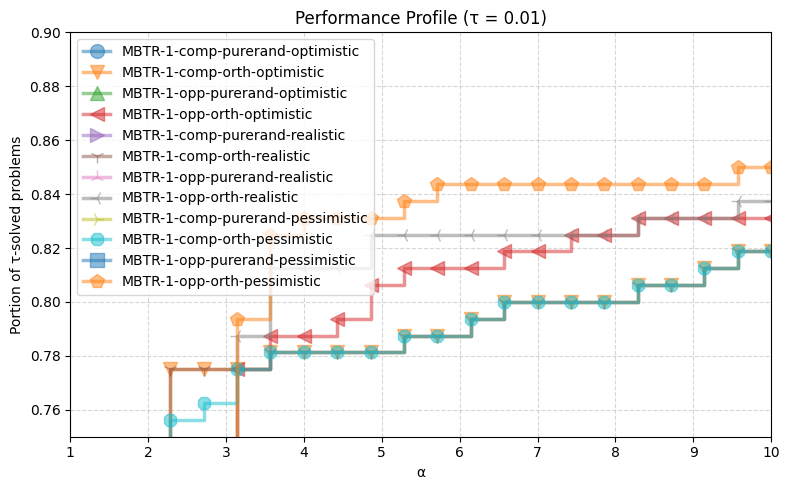

In [65]:
tau = 0.01
alpha_vals = torch.linspace(1, 10, 22)

profile_vals = profiles.performance_profile(num_algs_subset, len(log_paths_subset[0]), log_paths_subset, tau, alpha_vals=alpha_vals)
profiles.plot_performance_profile(profile_vals, tau, alg_names_subset, alpha_vals=alpha_vals, min_y=0.75, max_y=0.9, legend_on_side=False, alpha=0.5)

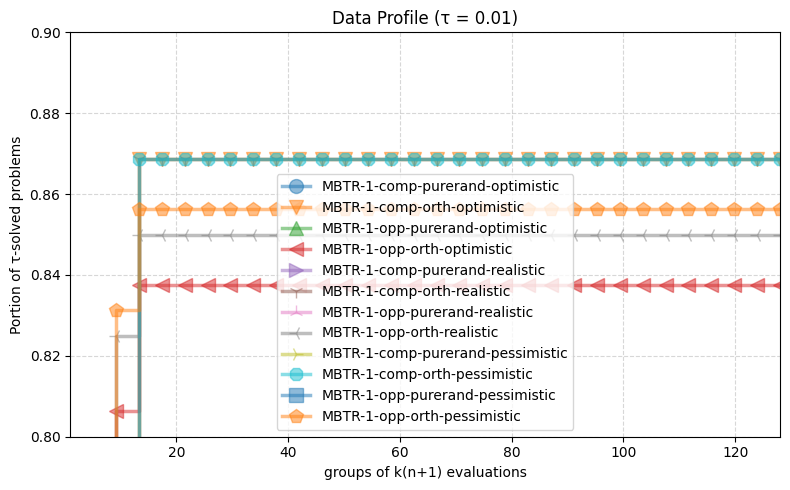

In [66]:
tau = 0.01
k_vals = torch.linspace(1, 128, 32)

problem_dims = torch.zeros(len(log_paths_subset[0]))
for i in range(len(log_paths_subset[0])):
    _problem_name = os.path.basename(log_paths_subset[0][i]).split("_")[2]
    problem_dims[i] = name_to_problem[_problem_name].n

profile_vals = profiles.data_profile(num_algs_subset, len(log_paths_subset[0]), log_paths_subset, tau, problem_dims, k_vals)
profiles.plot_data_profile(profile_vals, tau, alg_names_subset, k_vals, min_y=0.8, max_y=0.9, legend_on_side=False, alpha=0.5)

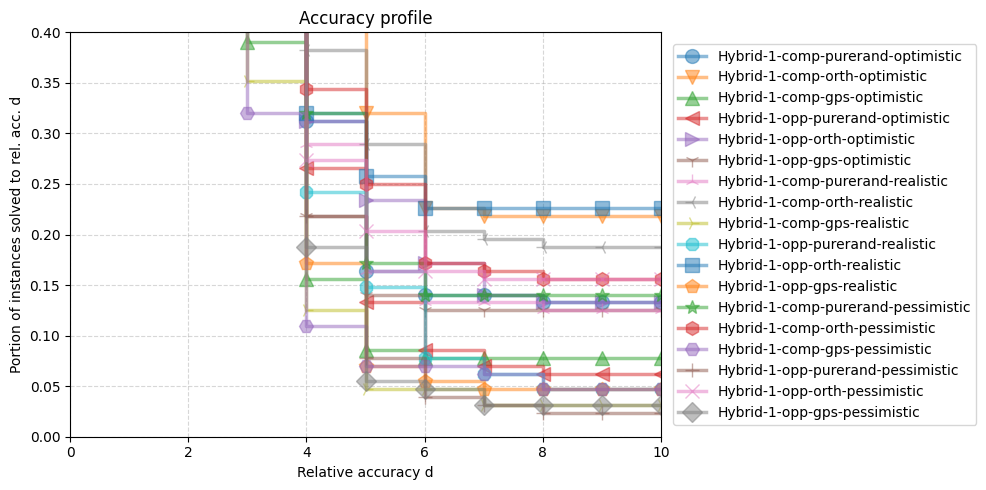

In [60]:
d_vals = torch.linspace(0, 10, 11)

profile_vals = profiles.accuracy_profile(num_algs_subset, len(log_paths_subset[0]), log_paths_subset, d_vals)
profiles.plot_accuracy_profile(profile_vals, alg_names_subset, d_vals, min_y=0., max_y=0.4, legend_on_side=True, alpha=0.5)